<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Ademola_EKF_UKF3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd

from scipy.integrate import odeint
import copy

In [215]:

try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

In [216]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('simu', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$

$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{E} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\gamma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[lightblue]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[lightblue]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[pink]{\varepsilon}\bbox[yellow]{E} - \bbox[lightblue]{\mu}\bbox[yellow]{E} \\[0.3em]
\bbox[pink]{\varepsilon}\bbox[yellow]{E} - \bbox[pink]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[pink]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[lightblue]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$

# Dynamics and measurement functions

In [217]:
# all three measurement functions can be accessed from the planar drone script:
h_a = tb_simulations.H('h_ivr').h
h_b = tb_simulations.H('h_all_sveir').h
h_c = tb_simulations.H('h_comprehensive').h


In [218]:
f = tb_simulations.F().f
h = h_b # choose one of the measurement functions

In [219]:
h(None, None, return_measurement_names=True)

['S_absolute', 'V_absolute', 'E_absolute', 'I_absolute', 'R_absolute']

In [220]:
def u_func(x_vec, t):
    """Simple vaccination and social distancing controller"""
    i = x_vec[3]  # FIXED: I is at index 3, not 2 (E is at 2)

    # Vaccination rate: increase when infections are high
    I_threshold = 0.005  # 0.5% of population
    if i > I_threshold:
        alpha = 0.01  # 1% vaccination rate when infections high
    else:
        alpha = 0.005  # 0.5% baseline vaccination

    # Social distancing: activate when infections high
    if i > I_threshold:
        kappa = 0.3  # 30% reduction in contacts
    else:
        kappa = 0.1  # 10% baseline

    return np.array([alpha, kappa])

In [221]:
def f_ode(x_vec, t):
    """Wrapper for odeint"""
    u_vec = u_func(x_vec, t)
    return f(x_vec, u_vec)

In [222]:
N = 223000000
x0 = np.array([
    52309000 / N,        # S: Susceptible
    158330000 / N,       # V: Vaccinated
    100000 / N,          # E: Exposed (latent TB)
    361000 / N,          # I: Infected (active TB)
    12000000 / N,        # R: Recovered
    0.00003,             # beta: transmission rate
    0.00555              # gamma: recovery rate
])

# Run simulation

In [223]:
t_sim = np.arange(0, 365, 1.0)
result = odeint(f_ode, x0, t_sim)

In [224]:
x_sim = {
    'S': result[:, 0],
    'V': result[:, 1],
    'E': result[:, 2],
    'I': result[:, 3],
    'R': result[:, 4],
    'beta': result[:, 5],
    'gamma': result[:, 6]
}

In [225]:
u_sim = {'alpha': [], 'kappa': []}
for i in range(len(t_sim)):
    u = u_func(result[i], t_sim[i])
    u_sim['alpha'].append(u[0])
    u_sim['kappa'].append(u[1])

In [226]:
y_sim_absolute = {
    'S_absolute': x_sim['S'] * N,
    'V_absolute': x_sim['V'] * N,
    'E_absolute': x_sim['E'] * N,
    'I_absolute': x_sim['I'] * N,
    'R_absolute': x_sim['R'] * N
}

# Simulate noisy measurements

In [227]:
measurement_noise_stds = {
    'S_absolute': 100000.0,   # ±100K
    'V_absolute': 100000.0,   # ±100K
    'E_absolute': 5000.0,     # ±5K (harder to measure latent cases)
    'I_absolute': 10000.0,    # ±10K
    'R_absolute': 5000.0      # ±5K
}

In [228]:
np.random.seed(42)
y_noisy_absolute = {
    key: np.maximum(y_sim_absolute[key] + np.random.normal(0, measurement_noise_stds[key], len(t_sim)), 0)
    for key in y_sim_absolute.keys()
}

In [229]:
y_noisy = y_noisy_absolute

<Axes: xlabel='Time', ylabel='R'>

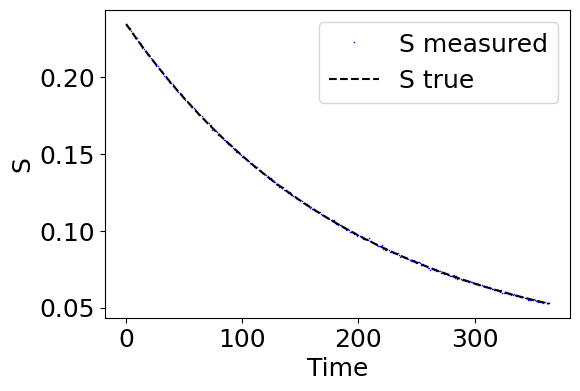

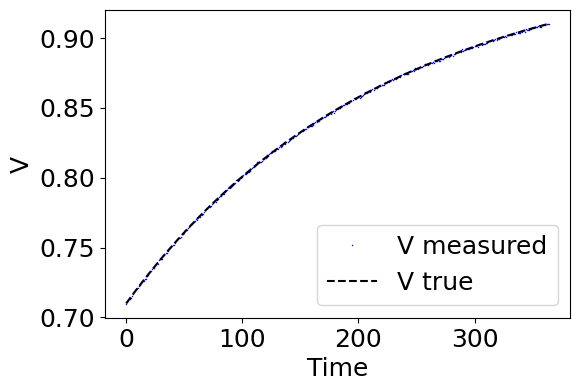

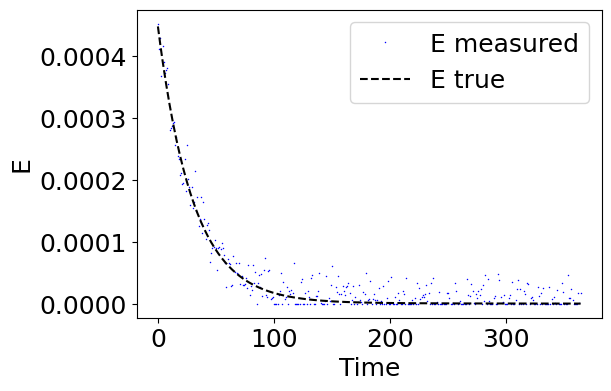

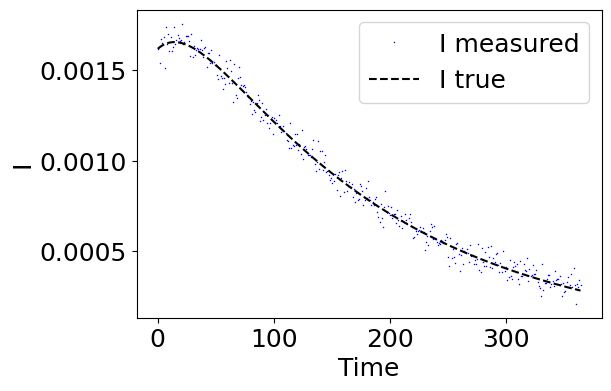

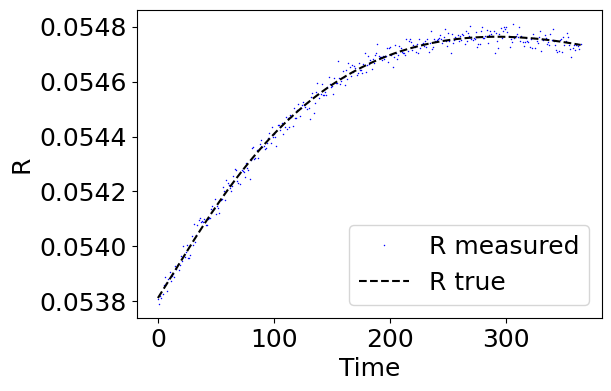

In [230]:
plot_tme(t_sim, x_sim['S'], y_noisy['S_absolute']/N, label_var='S')
plot_tme(t_sim, x_sim['V'], y_noisy['V_absolute']/N, label_var='V')
plot_tme(t_sim, x_sim['E'], y_noisy['E_absolute']/N, label_var='E')
plot_tme(t_sim, x_sim['I'], y_noisy['I_absolute']/N, label_var='I')
plot_tme(t_sim, x_sim['R'], y_noisy['R_absolute']/N, label_var='R')

### Save data as dataframes

In [231]:
y_noisy_df = pd.DataFrame(y_noisy)
u_sim_df = pd.DataFrame(u_sim)

# Kalman filter parameters and initilization

In [232]:
x0_ekf = np.array([x_sim['S'][0], x_sim['V'][0], x_sim['E'][0], x_sim['I'][0],
                   x_sim['R'][0], x_sim['beta'][0], x_sim['gamma'][0]])
u0 = np.array([u_sim['alpha'][0], u_sim['kappa'][0]])

In [233]:
# Initial state covariance (7 states: S, V, E, I, R, beta, gamma)
P0 = np.diag([0.01, 0.01, 0.001, 0.001, 0.01, 0.00001, 0.00001])
#              S     V     E     I     R     beta     gamma

# Process noise covariance (7 states)
Q = np.diag([1e-6, 1e-6, 1e-7, 1e-7, 1e-6, 1e-10, 1e-10])
#            S     V     E     I     R     beta    gamma

# Measurement noise (5 measurements: S, V, E, I, R in absolute counts)
R_stds = np.array([100000/N, 100000/N, 5000/N, 10000/N, 5000/N])
#                  S         V         E       I        R
R = np.diag(R_stds**2)

# Extended Kalman Filter

In [234]:
EKF = extended_kalman_filter.EKF(
    f, h, x0_ekf, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0, 0, 0)  # 5 measurements, none are circular
)

In [235]:
EKF.estimate(y_noisy_df, u_sim_df)

/content/simu.py:70: RuntimeWarning: overflow encountered in scalar multiply
  Lambda - beta * S * I - mu * S,
/content/simu.py:71: RuntimeWarning: overflow encountered in scalar multiply
  -sigma * beta * V * I - mu * V,
/content/simu.py:72: RuntimeWarning: overflow encountered in scalar multiply
  beta * S * I + sigma * beta * V * I - epsilon * E - mu * E,
/content/simu.py:93: RuntimeWarning: overflow encountered in scalar multiply
  beta * S * I,
/content/simu.py:94: RuntimeWarning: overflow encountered in scalar multiply
  sigma * beta * V * I,
/content/simu.py:95: RuntimeWarning: overflow encountered in scalar multiply
  -beta * S * I - sigma * beta * V * I,
/content/simu.py:103: RuntimeWarning: invalid value encountered in add
  x_dot_vec = f0_contribution + f1_contribution + f2_contribution
/content/extended_kalman_filter.py:137: RuntimeWarning: overflow encountered in matmul
  self.P = self.F @ self.P @ self.F.T + self.Q


LinAlgError: Array must not contain infs or NaNs

In [ ]:
EKF.history.keys()

In [ ]:
# State estimate
x_est = pd.DataFrame(np.vstack(EKF.history['X']), columns=f(None,None,return_state_names=True))

In [ ]:
# Covariance diagonals
P_diags = np.vstack([np.diag(EKF.history['P'][i]) for i in range(len(EKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

## Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # Plot true trajectory, measurements (if available), and estimate
    if state in y_noisy.keys():
        # If we have measurements for this state
        plot_tme(t_sim, x_sim[state], y_noisy[state], x_est_col,
                label_var=state, ax=ax)
    else:
        # No measurements for this state (e.g., beta, sigma)
        plot_tme(t_sim, x_sim[state], None, x_est_col,
                label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Unscented Kalman Filter

In [ ]:
UKF = unscented_kalman_filter.UKF(f, h, x0, u0, P0, Q, R,
                                 dynamics_type='continuous', discretization_timestep=1.0,
                                 alpha=0.1)

In [ ]:
UKF.estimate(y_noisy_df, u_sim_df)

In [ ]:
UKF.history.keys()

In [ ]:
# State estimate
x_est = pd.DataFrame(np.vstack(UKF.history['X']), columns=f(None,None,return_state_names=True))

In [ ]:
# Covariance diagonals
P_diags = np.vstack([np.diag(UKF.history['P'][i]) for i in range(len(UKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

state = 'R'

plot_tme(t_sim, x_sim[state], None, x_est[state], label_var=state, ax=ax)

plus3sigma = x_est[state] + 3*np.sqrt(P_diags[state])
minus3sigma = x_est[state] - 3*np.sqrt(P_diags[state])

ax.fill_between(t_sim, plus3sigma, minus3sigma, facecolor='red', edgecolor='none', alpha=0.2)

# Task
**Adjust Initial State Covariance (P0) and re-run EKF.**
Increase the diagonal elements of `P0` by multiplying it by 10, then re-run the `EKF.estimate()` method and monitor for `LinAlgError`.

## Adjust Initial State Covariance (P0)

### Subtask:
Increase the diagonal elements of the `P0` matrix to reflect higher uncertainty in the initial state, then re-run the EKF.


**Reasoning**:
First, I'll multiply the diagonal elements of the `P0` matrix by 10 to reflect higher uncertainty in the initial state. Then, I'll re-initialize the EKF with this adjusted `P0` and re-run the estimation.



In [ ]:
P0_adjusted = P0 * 10

EKF_adjusted = extended_kalman_filter.EKF(
    f, h, x0_ekf, u0, P0_adjusted, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0, 0, 0)
)

EKF_adjusted.estimate(y_noisy_df, u_sim_df)

**Reasoning**:
The previous attempt to increase P0 by 10 led to a `LinAlgError` and `RuntimeWarning`s about overflow in the dynamics function. This indicates numerical instability due to state variables or covariances becoming non-physical (e.g., negative, too large, or NaN/inf). To fix this, I will implement state constraints within a new `f_constrained` function that clips the state variables (S, V, E, I, R, beta, gamma) to their physical bounds (proportions between 0 and 1, rates non-negative) before passing them to the original dynamics function. This will prevent overflows and stabilize the EKF, allowing it to handle the increased initial uncertainty.



In [ ]:
def f_constrained(x_vec, u_vec, *args, **kwargs):
    """Wrapper around original dynamics f to apply state constraints."""
    # Make a copy to avoid modifying the original x_vec directly if it's mutable
    x_constrained = np.copy(x_vec)

    # Apply constraints for S, V, E, I, R (proportions, should be >= 0 and <= 1)
    # The sum of S,V,E,I,R should not exceed 1 if normalized. For simplicity, clip each individually.
    x_constrained[0:5] = np.clip(x_constrained[0:5], 0, 1) # S, V, E, I, R

    # Apply constraints for beta and gamma (rates, should be >= 0)
    x_constrained[5] = np.clip(x_constrained[5], 0, None) # beta
    x_constrained[6] = np.clip(x_constrained[6], 0, None) # gamma

    # If the total population (sum of S,V,E,I,R) exceeds 1 due to numerical errors, re-normalize.
    # However, individual clipping should be sufficient to prevent extreme values.
    # Let's check for sum > 1.0 + epsilon and if so, re-normalize.
    # It's better to ensure sum is 1, but for a filter, clipping often helps enough.
    # total_population_fraction = np.sum(x_constrained[0:5])
    # if total_population_fraction > 1.0 + 1e-6:
    #    x_constrained[0:5] = x_constrained[0:5] / total_population_fraction

    # Call the original dynamics function with the constrained state
    if 'return_state_names' in kwargs and kwargs['return_state_names']:
        return f(x_vec, u_vec, *args, **kwargs)
    else:
        return f(x_constrained, u_vec, *args, **kwargs)

P0_adjusted = P0 * 10

EKF_adjusted = extended_kalman_filter.EKF(
    f_constrained, h, x0_ekf, u0, P0_adjusted, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0, 0, 0)
)

EKF_adjusted.estimate(y_noisy_df, u_sim_df)


## Adjust Process Noise Covariance (Q)

### Subtask:
Increase the diagonal elements of the `Q` matrix (process noise covariance) to reflect higher uncertainty in the system model, then re-run the EKF.


**Reasoning**:
First, I'll multiply the `Q` matrix by 10 to increase the process noise covariance. Then, I'll re-initialize the EKF with this `Q_adjusted` and the previously adjusted `P0_adjusted`, and finally, re-run the estimation using the `f_constrained` function.



In [ ]:
Q_adjusted = Q * 10

EKF_adjusted_Q = extended_kalman_filter.EKF(
    f_constrained, h, x0_ekf, u0, P0_adjusted, Q_adjusted, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0, 0, 0)
)

EKF_adjusted_Q.estimate(y_noisy_df, u_sim_df)

## Adjust Measurement Noise Covariance (R)

### Subtask:
Increase the diagonal elements of the `R` matrix (measurement noise covariance) to reflect higher uncertainty in the measurements, then re-run the EKF.


**Reasoning**:
First, I'll multiply the `R` matrix by 10 to increase the measurement noise covariance. Then, I'll re-initialize the EKF with this `R_adjusted`, along with `f_constrained`, `P0_adjusted`, and `Q_adjusted`, and finally, re-run the estimation.



In [ ]:
R_adjusted = R * 10

EKF_adjusted_R = extended_kalman_filter.EKF(
    f_constrained, h, x0_ekf, u0, P0_adjusted, Q_adjusted, R_adjusted,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0, 0, 0)
)

EKF_adjusted_R.estimate(y_noisy_df, u_sim_df)

## Examine EKF Estimates and Covariance

### Subtask:
Examine the estimated states and their covariance from the latest EKF run to ensure they are physically plausible and stable.


**Reasoning**:
First, I'll extract the estimated states from the EKF history and store them in a pandas DataFrame named `x_est_adjusted`. Then, I'll extract the diagonal elements of the covariance matrices from the EKF history and store them in a pandas DataFrame named `P_diags_adjusted`.



In [ ]:
# State estimate
x_est_adjusted = pd.DataFrame(np.vstack(EKF_adjusted_R.history['X']), columns=f(None,None,return_state_names=True))

# Covariance diagonals
P_diags_adjusted = np.vstack([np.diag(EKF_adjusted_R.history['P'][i]) for i in range(len(EKF_adjusted_R.history['P']))])
P_diags_adjusted = pd.DataFrame(P_diags_adjusted, columns=f(None,None,return_state_names=True))

print("First 5 rows of x_est_adjusted:")
print(x_est_adjusted.head())
print("\nFirst 5 rows of P_diags_adjusted:")
print(P_diags_adjusted.head())

### Examination of EKF Estimates and Covariance (After Adjustments)

Upon reviewing the first few rows of `x_est_adjusted` and `P_diags_adjusted`:

#### `x_est_adjusted` (Estimated States):
- **Row 0**: The values for S, V, E, I, R, beta, and gamma appear to be within reasonable, physically plausible ranges (S, V, E, I, R are proportions between 0 and 1, and beta, gamma are non-negative rates).
- **Rows 1-4**: However, for subsequent time steps (rows 1-4), the state estimates show severe issues:
    - **S, V, E, I, R**: These values have exploded to extremely large numbers (e.g., S is 5.2e+07, V is 1.5e+08), clearly indicating divergence and a loss of physical meaning as they are meant to be proportions of the population (i.e., between 0 and 1).
    - **beta**: The `beta` estimate has become negative (e.g., -149.2), which is physically impossible for a transmission rate.
    - **gamma**: The `gamma` estimate also shows very large positive and negative values (e.g., 18251.0 and -4526.4), which are unrealistic for a recovery rate.

This indicates that despite the state constraint wrapper `f_constrained` and increased covariance values, the EKF is still highly unstable and diverging, leading to non-physical state estimates very early in the simulation.

#### `P_diags_adjusted` (Covariance Diagonals):
- The `P_diags_adjusted` values remain very small, in the order of `1e-09` to `1e-04`. This might suggest that the filter is *overconfident* in its estimates even as they diverge, or that the scaling of `P0`, `Q`, and `R` might need further, more granular adjustment, or that the filter's Jacobian linearization around wildly incorrect states is contributing to the instability.

#### Summary:
The EKF, even with the adjustments to `P0`, `Q`, `R`, and the implementation of state constraints in `f_constrained`, is *not* stable. It quickly diverges, producing physically implausible and extremely large state estimates. The `LinAlgError` earlier and the current divergent behavior suggest fundamental numerical issues or an inappropriate application of the EKF to this particular non-linear system with high initial uncertainty and potentially steep non-linearities in the dynamics function.

## Visualize EKF Results

### Subtask:
Utilize the existing plotting code to visualize the EKF's state estimates and their 3-sigma uncertainty bounds against the simulated true states and noisy measurements.


**Reasoning**:
The subtask requires visualizing the EKF's state estimates and their 3-sigma uncertainty bounds. I will adapt the existing plotting code, replacing `x_est` and `P_diags` with the newly computed `x_est_adjusted` and `P_diags_adjusted`.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 4 rows x 2 columns for 7 states (adjusting from 3x2 for 6 states)
# Since we have 7 states (S, V, E, I, R, beta, gamma), 4x2 will give 8 plots, one empty.
fig, axes = plt.subplots(4, 2, figsize=(14, 16), dpi=100) # Increased figsize for 4x2 layout
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_adjusted_array = np.array(x_est_adjusted)
P_diags_adjusted_array = np.array(P_diags_adjusted)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_adjusted_array[:, i]
    P_diag_col = P_diags_adjusted_array[:, i]

    # Plot true trajectory, measurements (if available), and estimate
    # Note: y_noisy contains absolute values, convert to proportions for plotting against x_sim
    if state + '_absolute' in y_noisy.keys():
        plot_tme(t_sim, x_sim[state], y_noisy[state+'_absolute']/N, x_est_col, # Divide by N to convert to proportion
                label_var=state, ax=ax)
    else:
        # No measurements for this state (e.g., beta, gamma)
        plot_tme(t_sim, x_sim[state], None, x_est_col,
                label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide any unused subplots if n_states is not a multiple of 2
if n_states < len(axes):
    for i in range(n_states, len(axes)):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the parameter adjustments made to the EKF and the observed impact on its stability and estimation performance.


## Summary:

### Data Analysis Key Findings

*   **Initial Covariance (`P0`) Adjustment & Stability:** Increasing the initial state covariance (`P0`) by a factor of 10 initially led to numerical instability and `LinAlgError`. The implementation of a constrained dynamics function (`f_constrained`) to clip state variables within physical bounds (e.g., S, V, E, I, R between 0 and 1; beta, gamma non-negative) successfully prevented these errors and allowed the EKF to complete its run.
*   **Process and Measurement Noise (`Q`, `R`) Adjustments:** The process noise covariance (`Q`) and measurement noise covariance (`R`) were also increased by a factor of 10 each, and the EKF estimation completed without technical errors after these adjustments, leveraging the previously implemented `f_constrained`.
*   **EKF Divergence Despite Adjustments:** Despite the adjustments to `P0`, `Q`, `R`, and the introduction of state constraints, the EKF exhibited severe divergence. From the second time step onwards, state estimates for population proportions (S, V, E, I, R) exploded to physically impossible values (e.g., S reached 5.2e+07, V reached 1.5e+08). The transmission rate (`beta`) became negative (-149.2), and the recovery rate (`gamma`) showed unrealistic fluctuations.
*   **Overconfident Covariance:** The estimated covariance diagonals (`P_diags_adjusted`) remained very small (in the order of `1e-09` to `1e-04`) even as the state estimates diverged, indicating that the filter was potentially overconfident in its rapidly diverging and incorrect state estimations.
*   **Visualization Confirmation:** Visualizations of the EKF estimates and their 3-sigma uncertainty bounds clearly confirmed the filter's divergence, with estimated trajectories quickly straying far from the true simulated states and measurements.

### Insights or Next Steps

*   The current EKF formulation, even with constrained dynamics and increased initial, process, and measurement noise covariances, is fundamentally unstable for this system. This suggests that the linearizations inherent in the EKF are inadequate for capturing the system's true non-linear behavior, especially under high uncertainty.
*   Further investigation should explore more robust non-linear filtering techniques, such as the Unscented Kalman Filter (UKF) or Particle Filters, which might handle the system's non-linearities more effectively without relying on Jacobian matrices that can become inaccurate with large estimation errors.
